In [1]:
"""
==============================================================
  MODEL OPTIMIZATION IN TENSORFLOW/KERAS
  Topics: Overfitting | Learning Rate | Batch Size | Callbacks
  Audience: Freshers / Beginners
==============================================================
"""

# ── IMPORTS ──────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    TensorBoard,
)

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.15.0


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 1 — GENERATE TOY DATASET
# We use a simple binary classification dataset so students
# can focus on the optimization concepts, not data wrangling.
# ─────────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

NUM_SAMPLES = 1000
X = np.random.randn(NUM_SAMPLES, 20).astype("float32")   # 20 features
y = (X[:, 0] + X[:, 1] > 0).astype("float32")            # simple rule

# Split: 70% train | 15% val | 15% test
split1 = int(0.70 * NUM_SAMPLES)
split2 = int(0.85 * NUM_SAMPLES)
X_train, y_train = X[:split1],  y[:split1]
X_val,   y_val   = X[split1:split2], y[split1:split2]
X_test,  y_test  = X[split2:], y[split2:]

print(f"\nDataset shapes  →  train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}")


Dataset shapes  →  train: (700, 20)  val: (150, 20)  test: (150, 20)


In [3]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 — HELPER: BUILD MODEL
# ─────────────────────────────────────────────────────────────
def build_model(use_dropout=False, use_l2=False, dropout_rate=0.4):
    """
    Build a small fully-connected network.

    Parameters
    ----------
    use_dropout : bool   → add Dropout layers (fights overfitting)
    use_l2      : bool   → add L2 weight regularisation (fights overfitting)
    dropout_rate: float  → fraction of neurons to randomly drop
    """
    reg = keras.regularizers.l2(1e-3) if use_l2 else None

    model = keras.Sequential(name="demo_model")
    model.add(layers.Input(shape=(20,)))

    # Hidden layers
    for units in [128, 64, 32]:
        model.add(layers.Dense(units, activation="relu",
                               kernel_regularizer=reg))
        if use_dropout:
            model.add(layers.Dropout(dropout_rate))

    # Output layer – sigmoid for binary classification
    model.add(layers.Dense(1, activation="sigmoid"))
    return model


SECTION 3: Overfitting Demo


  Training: Overfit (no regularisation) ...



  Training: Dropout regularisation ...

  Training: L2 regularisation ...


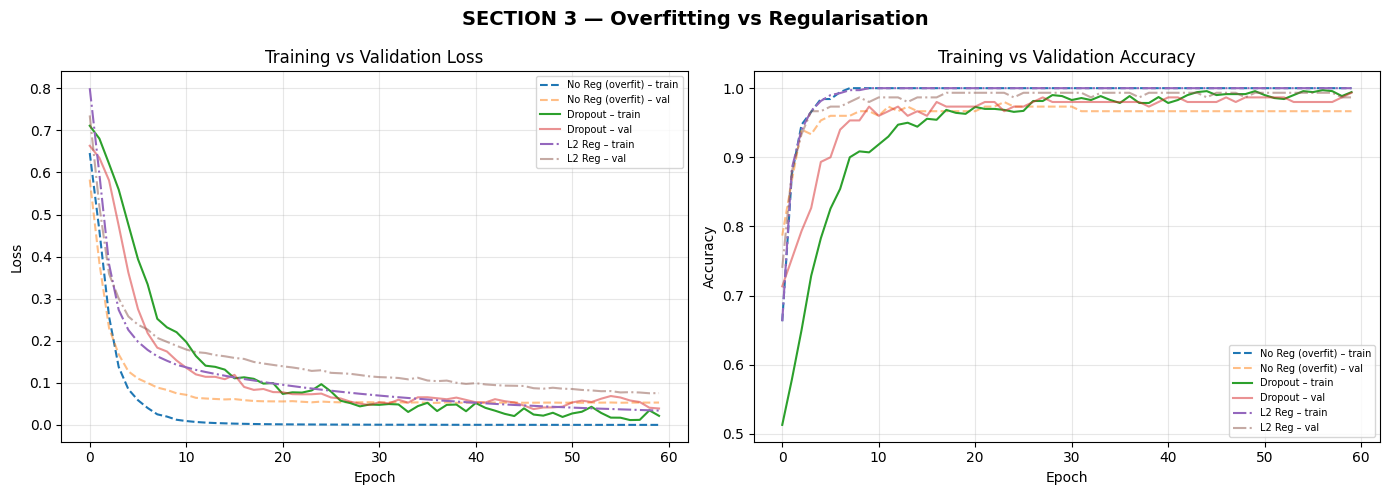

  ✅ Saved: overfitting_demo.png

  📌 KEY INSIGHT — Overfitting:
     • 'No Reg' model: training loss drops but val loss RISES → OVERFIT
     • Dropout / L2 keep val loss closer to train loss → healthier model
     • Gap between train & val metrics = measure of overfitting



In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 3 — OVERFITTING DEMO
# Train a huge model WITHOUT regularisation  →  see it overfit
# Then add Dropout / L2  →  see validation loss stay healthy
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SECTION 3: Overfitting Demo")
print("="*60)

def train_and_return_history(model, label, epochs=60, batch_size=32):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    print(f"\n  Training: {label} ...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,          # silent – we plot instead
    )
    return history

# ── Model A: No regularisation (will overfit) ──
model_overfit = build_model(use_dropout=False, use_l2=False)
history_overfit = train_and_return_history(model_overfit, "Overfit (no regularisation)")

# ── Model B: With Dropout ──
model_dropout = build_model(use_dropout=True)
history_dropout = train_and_return_history(model_dropout, "Dropout regularisation")

# ── Model C: With L2 ──
model_l2 = build_model(use_l2=True)
history_l2 = train_and_return_history(model_l2, "L2 regularisation")

# ── Plot comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SECTION 3 — Overfitting vs Regularisation", fontsize=14, fontweight="bold")

for ax, metric, title in zip(
    axes,
    ["loss", "accuracy"],
    ["Loss", "Accuracy"],
):
    for history, label, style in [
        (history_overfit, "No Reg (overfit)", "--"),
        (history_dropout, "Dropout",          "-"),
        (history_l2,      "L2 Reg",           "-."),
    ]:
        ax.plot(history.history[metric],          linestyle=style, label=f"{label} – train")
        ax.plot(history.history[f"val_{metric}"], linestyle=style, alpha=0.5, label=f"{label} – val")
    ax.set_title(f"Training vs Validation {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("overfitting_demo.png", dpi=150)
plt.show()
print("  Saved: overfitting_demo.png")

# KEY INSIGHT for students ──────────────────────────────────────
print("""
     KEY INSIGHT — Overfitting:
     - 'No Reg' model: training loss drops but val loss RISES → OVERFIT
     - Dropout / L2 keep val loss closer to train loss → healthier model
     - Gap between train & val metrics = measure of overfitting
""")

SECTION 4: Learning Rate Demo
  Training with LR = 0.1 ...
  Training with LR = 0.001 ...
  Training with LR = 1e-05 ...


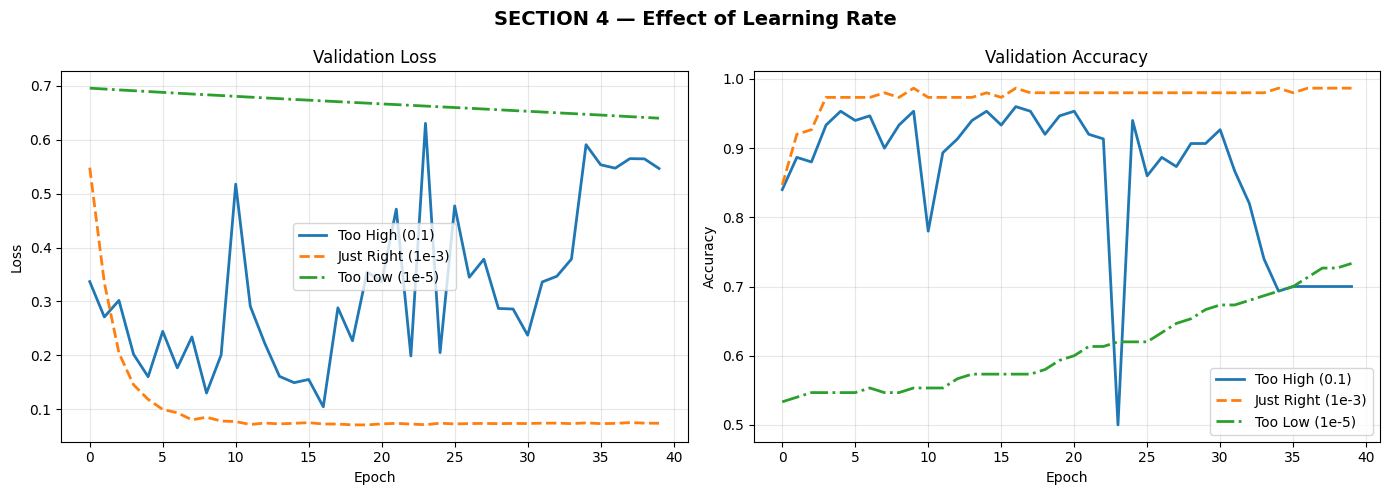

  ✅ Saved: learning_rate_demo.png

  📌 KEY INSIGHT — Learning Rate:
     • LR = step size the model takes when updating weights.
     • Too HIGH → overshoots minimum → loss bounces or diverges.
     • Too LOW  → tiny steps → takes forever to learn.
     • Typical starting point: 1e-3 (Adam), 1e-2 (SGD).



In [5]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 — LEARNING RATE DEMO
# Too high LR → unstable training (loss oscillates / diverges)
# Too low  LR → very slow convergence
# Just right   → smooth, fast convergence
# ─────────────────────────────────────────────────────────────
print("="*60)
print("SECTION 4: Learning Rate Demo")
print("="*60)

learning_rates = {
    "Too High (0.1)":   0.1,
    "Just Right (1e-3)": 1e-3,
    "Too Low (1e-5)":   1e-5,
}

lr_histories = {}
for label, lr in learning_rates.items():
    m = build_model()
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    print(f"  Training with LR = {lr} ...")
    h = m.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=40, batch_size=32, verbose=0)
    lr_histories[label] = h

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SECTION 4 — Effect of Learning Rate", fontsize=14, fontweight="bold")

styles = ["-", "--", "-."]
for ax, metric, title in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    for (label, h), style in zip(lr_histories.items(), styles):
        ax.plot(h.history[f"val_{metric}"], linestyle=style, linewidth=2, label=label)
    ax.set_title(f"Validation {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("learning_rate_demo.png", dpi=150)
plt.show()
print("  Saved: learning_rate_demo.png")

print("""
  KEY INSIGHT — Learning Rate:
     - LR = step size the model takes when updating weights.
     - Too HIGH → overshoots minimum → loss bounces or diverges.
     - Too LOW  → tiny steps → takes forever to learn.
     - Typical starting point: 1e-3 (Adam), 1e-2 (SGD).
""")



SECTION 5: Batch Size Demo
  Training with batch_size = 8 ...
  Training with batch_size = 64 ...
  Training with batch_size = 512 ...


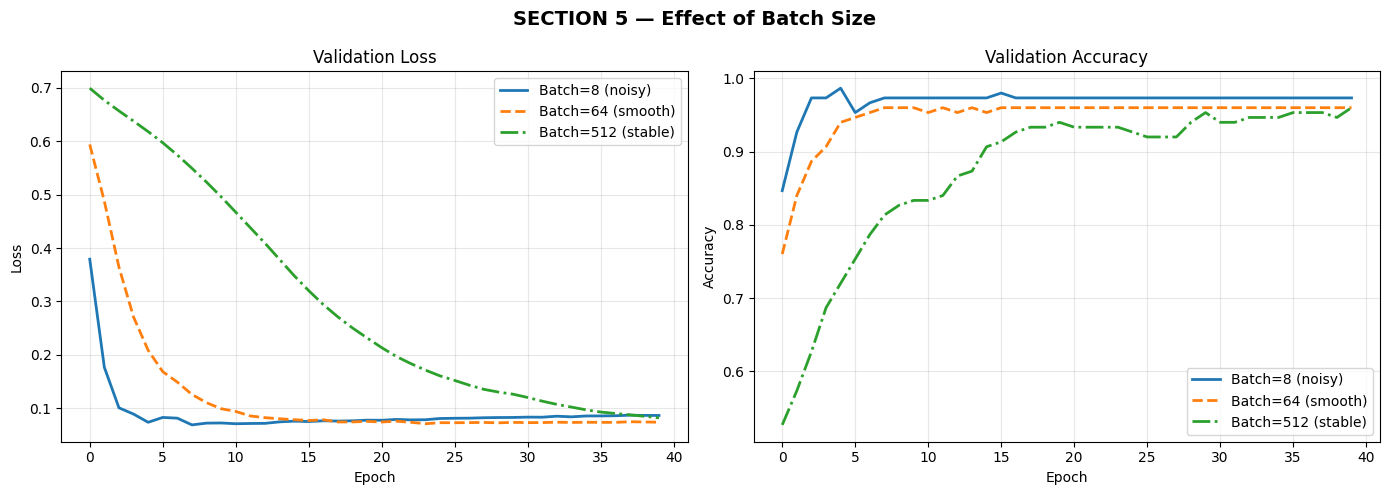

  ✅ Saved: batch_size_demo.png

  📌 KEY INSIGHT — Batch Size:
     • Small batch (8)  → noisy updates → more randomness, can escape local minima.
     • Large batch (512)→ smoother, faster per epoch, but may generalise less well.
     • Sweet spot: 32–128 for most problems.
     • Rule: if you double batch size, consider doubling LR too (linear scaling rule).



In [6]:
# ─────────────────────────────────────────────────────────────
# SECTION 5 — BATCH SIZE DEMO
# Batch size = how many samples we use before updating weights.
# ─────────────────────────────────────────────────────────────
print("="*60)
print("SECTION 5: Batch Size Demo")
print("="*60)

batch_sizes = {"Batch=8 (noisy)": 8, "Batch=64 (smooth)": 64, "Batch=512 (stable)": 512}

bs_histories = {}
for label, bs in batch_sizes.items():
    m = build_model()
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    print(f"  Training with batch_size = {bs} ...")
    h = m.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=40, batch_size=bs, verbose=0)
    bs_histories[label] = h

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SECTION 5 — Effect of Batch Size", fontsize=14, fontweight="bold")

for ax, metric, title in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    for (label, h), style in zip(bs_histories.items(), ["-", "--", "-."]):
        ax.plot(h.history[f"val_{metric}"], linestyle=style, linewidth=2, label=label)
    ax.set_title(f"Validation {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("batch_size_demo.png", dpi=150)
plt.show()
print("  Saved: batch_size_demo.png")

print("""
    KEY INSIGHT — Batch Size:
     - Small batch (8)  → noisy updates → more randomness, can escape local minima.
     - Large batch (512)→ smoother, faster per epoch, but may generalise less well.
     - Sweet spot: 32–128 for most problems.
     - Rule: if you double batch size, consider doubling LR too (linear scaling rule).
""")



SECTION 6: Callbacks Demo

  Training with EarlyStopping + ReduceLROnPlateau + ModelCheckpoint ...

Epoch 1/200
18/22 [=======================>......] - ETA: 0s - loss: 0.7195 - accuracy: 0.5191 
Epoch 1: val_accuracy improved from -inf to 0.74667, saving model to best_model.keras
22/22 [==============================] - 2s 19ms/step - loss: 0.7120 - accuracy: 0.5300 - val_loss: 0.5954 - val_accuracy: 0.7467 - lr: 0.0010
Epoch 2/200
18/22 [=======================>......] - ETA: 0s - loss: 0.6292 - accuracy: 0.6233
Epoch 2: val_accuracy improved from 0.74667 to 0.82667, saving model to best_model.keras
22/22 [==============================] - 0s 7ms/step - loss: 0.6159 - accuracy: 0.6443 - val_loss: 0.5094 - val_accuracy: 0.8267 - lr: 0.0010
Epoch 3/200
20/22 [==========================>...] - ETA: 0s - loss: 0.5420 - accuracy: 0.7344
Epoch 3: val_accuracy improved from 0.82667 to 0.88000, saving model to best_model.keras
22/22 [==============================] - 0s 7ms/step - loss: 0.54

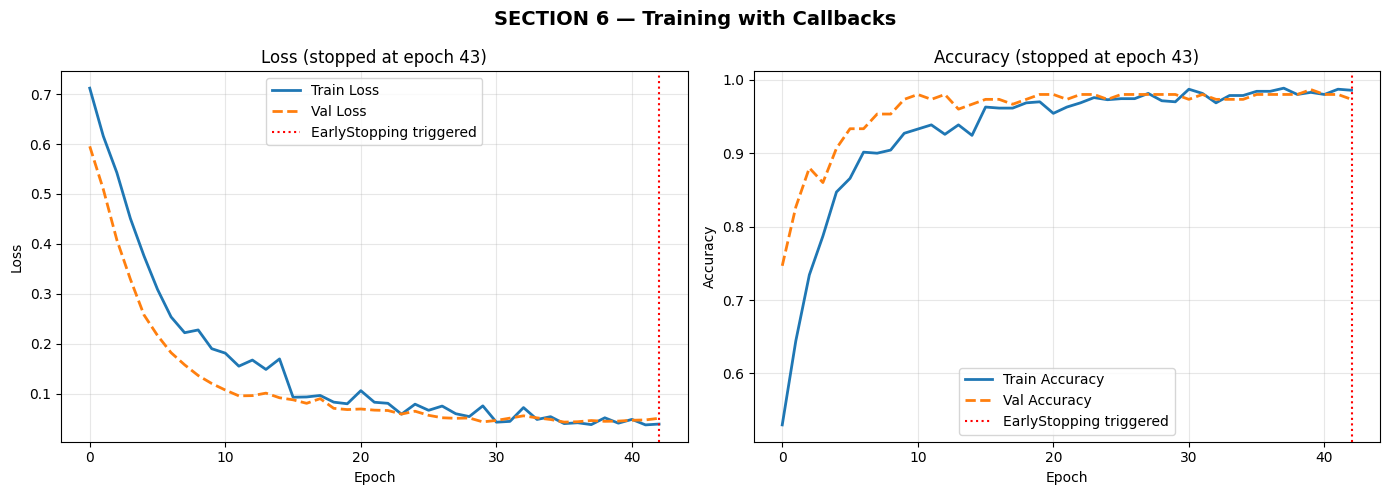

  Saved: callbacks_demo.png

    KEY INSIGHT — Callbacks:
     - EarlyStopping  → prevents wasted compute & overfitting by stopping early.
     - ReduceLROnPlateau → automatically fine-tunes LR during training.
     - ModelCheckpoint → you always keep the BEST model, not the last one.
     - Callbacks are registered via callbacks=[...] in model.fit().



In [7]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 — CALLBACKS DEMO
# Callbacks are functions that run automatically during training.
# We demo three essential ones:
#   1. EarlyStopping   – stop when val_loss stops improving
#   2. ReduceLROnPlateau – lower LR when training plateaus
#   3. ModelCheckpoint – save the best model automatically
# ─────────────────────────────────────────────────────────────
print("="*60)
print("SECTION 6: Callbacks Demo")
print("="*60)

# ── 6a. EarlyStopping ──────────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_loss",   # watch validation loss
    patience=7,           # stop after 7 epochs of no improvement
    restore_best_weights=True,  # roll back to best epoch's weights
    verbose=1,
)

# ── 6b. ReduceLROnPlateau ──────────────────────────────────
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,       # multiply LR by 0.5 when plateau detected
    patience=4,       # wait 4 epochs before reducing
    min_lr=1e-6,      # never go below this LR
    verbose=1,
)

# ── 6c. ModelCheckpoint ────────────────────────────────────
checkpoint = ModelCheckpoint(
    filepath="best_model.keras",   # save path
    monitor="val_accuracy",
    save_best_only=True,           # only save when val_accuracy improves
    verbose=1,
)

# ── Train with all callbacks ──────────────────────────────
model_cb = build_model(use_dropout=True)
model_cb.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("\n  Training with EarlyStopping + ReduceLROnPlateau + ModelCheckpoint ...\n")
history_cb = model_cb.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,          # set high – EarlyStopping will cut it short
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1,
)

# ── Plot callback training ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SECTION 6 — Training with Callbacks", fontsize=14, fontweight="bold")

for ax, metric, title in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    ax.plot(history_cb.history[metric],         label=f"Train {title}", linewidth=2)
    ax.plot(history_cb.history[f"val_{metric}"],label=f"Val {title}",   linewidth=2, linestyle="--")
    ax.axvline(x=len(history_cb.history[metric])-1,
               color="red", linestyle=":", label="EarlyStopping triggered")
    ax.set_title(f"{title} (stopped at epoch {len(history_cb.history[metric])})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("callbacks_demo.png", dpi=150)
plt.show()
print("  Saved: callbacks_demo.png")

print("""
    KEY INSIGHT — Callbacks:
     - EarlyStopping  → prevents wasted compute & overfitting by stopping early.
     - ReduceLROnPlateau → automatically fine-tunes LR during training.
     - ModelCheckpoint → you always keep the BEST model, not the last one.
     - Callbacks are registered via callbacks=[...] in model.fit().
""")

In [8]:
# ─────────────────────────────────────────────────────────────
# SECTION 7 — EVALUATE FINAL MODEL
# ─────────────────────────────────────────────────────────────
print("="*60)
print("SECTION 7: Final Evaluation on Test Set")
print("="*60)

test_loss, test_acc = model_cb.evaluate(X_test, y_test, verbose=0)
print(f"\n  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}")

# ── Model summary ──────────────────────────────────────────
print("\n  Model Architecture:")
model_cb.summary()

SECTION 7: Final Evaluation on Test Set

  Test Loss     : 0.0830
  Test Accuracy : 0.9600

  Model Architecture:
Model: "demo_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 128)               2688      
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_37 (Dense)            (None, 64)                8256      
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_38 (Dense)            (None, 32)                2080      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
        

In [9]:
# ─────────────────────────────────────────────────────────────
# SECTION 8 — QUICK REFERENCE CHEAT SHEET
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║           MODEL OPTIMIZATION — QUICK REFERENCE               ║
╠══════════════════════════════════════════════════════════════╣
║  OVERFITTING                                                 ║
║    • Symptom : train acc ↑  but  val acc ↓                   ║
║    • Fix 1   : Dropout(rate=0.3–0.5)                         ║
║    • Fix 2   : L2 regularisation (kernel_regularizer=l2())   ║
║    • Fix 3   : More training data / data augmentation        ║
║    • Fix 4   : Simpler model (fewer layers / neurons)        ║
╠══════════════════════════════════════════════════════════════╣
║  LEARNING RATE                                               ║
║    • Too high → loss oscillates or diverges                  ║
║    • Too low  → very slow convergence                        ║
║    • Default  : Adam lr=1e-3  |  SGD lr=1e-2                 ║
║    • Callback : ReduceLROnPlateau                            ║
╠══════════════════════════════════════════════════════════════╣
║  BATCH SIZE                                                  ║
║    • Small (8–16)  → noisy but regularising                  ║
║    • Large (256+)  → smooth but may overfit                  ║
║    • Sweet spot    → 32–128                                  ║
╠══════════════════════════════════════════════════════════════╣
║  CALLBACKS                                                   ║
║    • EarlyStopping      → stop training at the right time    ║
║    • ReduceLROnPlateau  → auto-adjust LR                     ║
║    • ModelCheckpoint    → save best weights automatically    ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           MODEL OPTIMIZATION — QUICK REFERENCE              ║
╠══════════════════════════════════════════════════════════════╣
║  OVERFITTING                                                 ║
║    • Symptom : train acc ↑  but  val acc ↓                  ║
║    • Fix 1   : Dropout(rate=0.3–0.5)                        ║
║    • Fix 2   : L2 regularisation (kernel_regularizer=l2())  ║
║    • Fix 3   : More training data / data augmentation        ║
║    • Fix 4   : Simpler model (fewer layers / neurons)        ║
╠══════════════════════════════════════════════════════════════╣
║  LEARNING RATE                                               ║
║    • Too high → loss oscillates or diverges                  ║
║    • Too low  → very slow convergence                        ║
║    • Default  : Adam lr=1e-3  |  SGD lr=1e-2                ║
║    • Callback : ReduceLROnPlateau                            ║
╠════════════════════════════